<a href="https://colab.research.google.com/github/hmurtaza720/5-Data-Science-Advanced-Internship-Tasks-/blob/main/Task1_Term_Deposit_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Problem Statement & Objective
Banks run phone-based marketing campaigns to convince customers to subscribe to **term deposits** — a fixed-term savings product. Not every customer says yes, and calling uninterested customers wastes resources.

**Goal:** Build a classification model to predict whether a customer will subscribe (`yes`) or not (`no`) based on their demographic profile, financial status, and campaign interaction history.

**Target Variable:** `y` — 1 (subscribed) or 0 (did not subscribe)

## Dataset
> **Bank Marketing Dataset — UCI Machine Learning Repository**
>
> **Direct Download (auto in notebook):** UCI public mirror
>
> Features include: age, job, marital status, education, balance, housing loan, contact type, duration, campaign calls, pdays, previous, poutcome

## Skills Demonstrated
- Classification modeling (Logistic Regression, Random Forest)
- Feature encoding (Label + One-Hot)
- Model evaluation: Confusion Matrix, F1-Score, ROC Curve
- **Explainable AI (XAI) using SHAP** — explaining 5+ individual predictions

## Step 1: Install & Import Libraries

In [ ]:
# Install required libraries
!pip install shap -q
# !pip install pandas numpy matplotlib seaborn scikit-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [ ]:
# Option A: Auto-download from UCI public mirror
import urllib.request, zipfile, io, os

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
try:
    print('Downloading Bank Marketing dataset from UCI...')
    resp = urllib.request.urlopen(url)
    zf = zipfile.ZipFile(io.BytesIO(resp.read()))
    zf.extractall('.')
    df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')
    print(f'Dataset loaded: {df.shape}')
except Exception as e:
    print(f'UCI download failed: {e}')
    print('Trying GitHub mirror...')
    try:
        url2 = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/bank.csv'
        df = pd.read_csv(url2)
        # Rename target column if needed
        if 'deposit' in df.columns:
            df.rename(columns={'deposit': 'y'}, inplace=True)
        print(f'Dataset loaded from mirror: {df.shape}')
    except Exception as e2:
        print(f'Both failed. Please upload bank.csv manually.')
        # from google.colab import files
        # uploaded = files.upload()
        # df = pd.read_csv('bank.csv', sep=';')

df.head()

Dataset loaded: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Step 3: Dataset Description & Loading

In [ ]:
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
df.info()

Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-n

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
# Target variable distribution
print('Target Variable (y) Distribution:')
print(df['y'].value_counts())
subscribe_rate = (df['y'] == 'yes').mean() if df['y'].dtype == object else df['y'].mean()
print(f'Subscription Rate: {subscribe_rate*100:.1f}%')
print('\nMissing Values:', df.isnull().sum().sum())

Target Variable (y) Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64
Subscription Rate: 11.3%

Missing Values: 0


## Step 4: Data Cleaning & Preprocessing

In [ ]:
# Replace 'unknown' with NaN and fill with mode
df.replace('unknown', np.nan, inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
print('Missing values after cleaning:', df.isnull().sum().sum())

# Encode target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0}) if df['y'].dtype == object else df['y']
print('Target encoded: yes=1, no=0')

Missing values after cleaning: 0
Target encoded: yes=1, no=0


In [ ]:
# One-Hot encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head(3)

Encoding 10 categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Shape after encoding: (41188, 48)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


## Step 5: Exploratory Data Analysis (EDA)

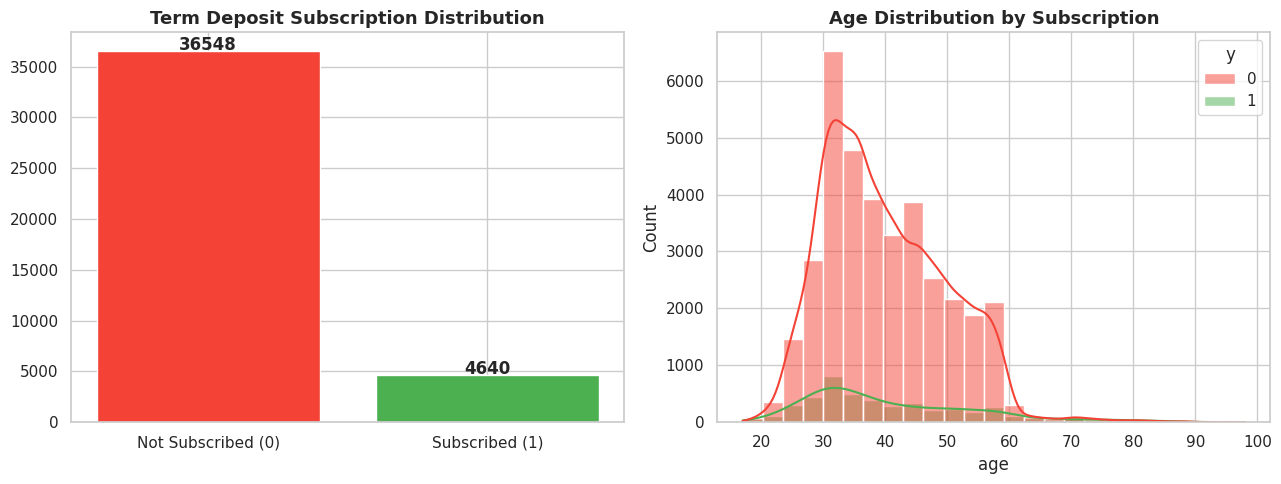

In [ ]:
# Target class balance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['y'].value_counts()
axes[0].bar(['Not Subscribed (0)', 'Subscribed (1)'], counts.values,
            color=['#F44336', '#4CAF50'], edgecolor='white')
axes[0].set_title('Term Deposit Subscription Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Age distribution by outcome
if 'age' in df.columns:
    sns.histplot(data=df, x='age', hue='y', bins=25, kde=True,
                 palette={0:'#F44336', 1:'#4CAF50'}, ax=axes[1])
    axes[1].set_title('Age Distribution by Subscription', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

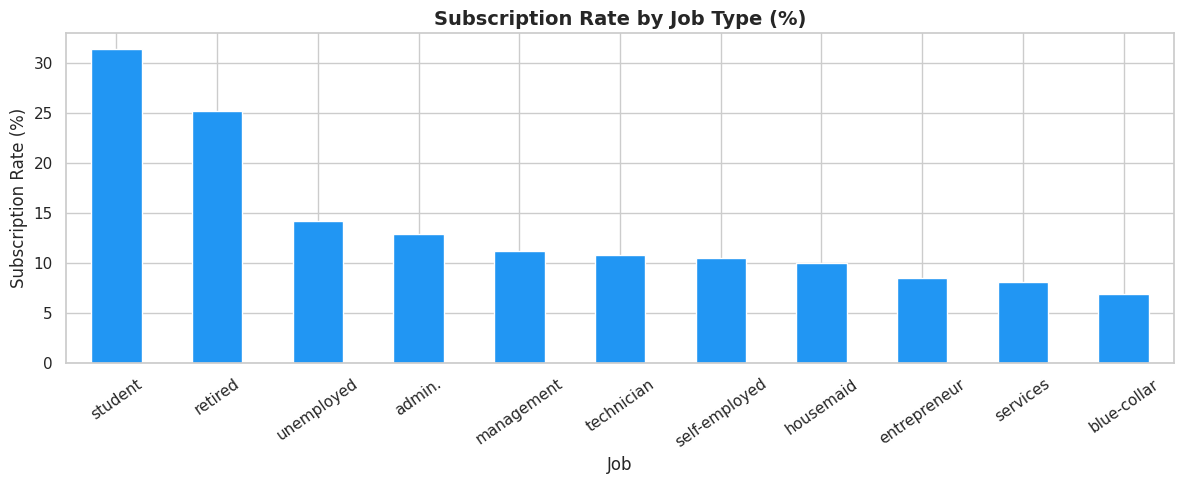

In [ ]:
# Subscription rate by job (if available)
if 'job' in df.columns:
    job_sub = df.groupby('job')['y'].mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(12, 5))
    job_sub.plot(kind='bar', color='#2196F3', edgecolor='white')
    plt.title('Subscription Rate by Job Type (%)', fontsize=14, fontweight='bold')
    plt.xlabel('Job')
    plt.ylabel('Subscription Rate (%)')
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

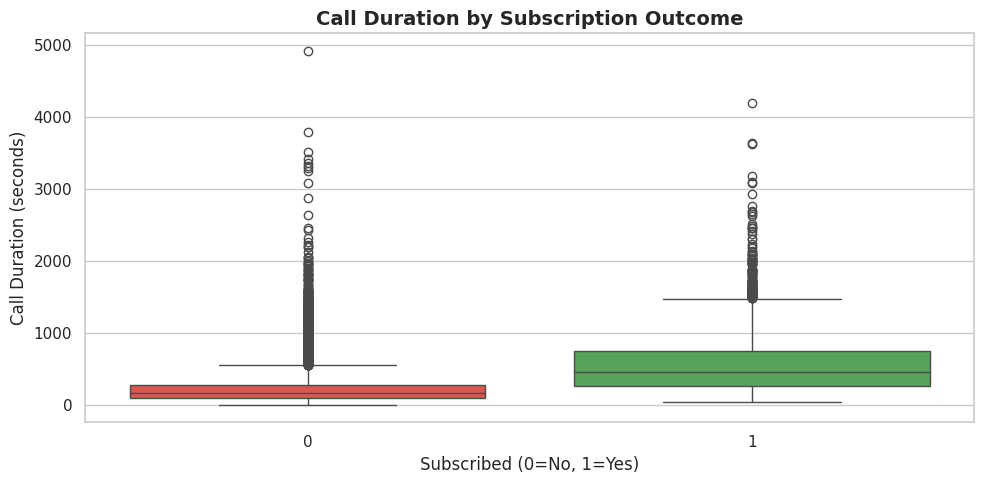

Avg Duration — Not Subscribed: 220.8
Avg Duration — Subscribed:     553.2


In [ ]:
# Call duration vs subscription
if 'duration' in df.columns:
    plt.figure(figsize=(10, 5))

    # Fix 1: Use string keys in the palette
    sns.boxplot(data=df, x='y', y='duration',
                palette={'0':'#F44336', '1':'#4CAF50'})

    plt.title('Call Duration by Subscription Outcome', fontsize=14, fontweight='bold')
    plt.xlabel('Subscribed (0=No, 1=Yes)')
    plt.ylabel('Call Duration (seconds)')
    plt.tight_layout()
    plt.show()

    # Fix 2: Ensure y is treated as an integer for the filtering math
    print('Avg Duration — Not Subscribed:', df[df['y'].astype(int)==0]['duration'].mean().round(1))
    print('Avg Duration — Subscribed:    ', df[df['y'].astype(int)==1]['duration'].mean().round(1))

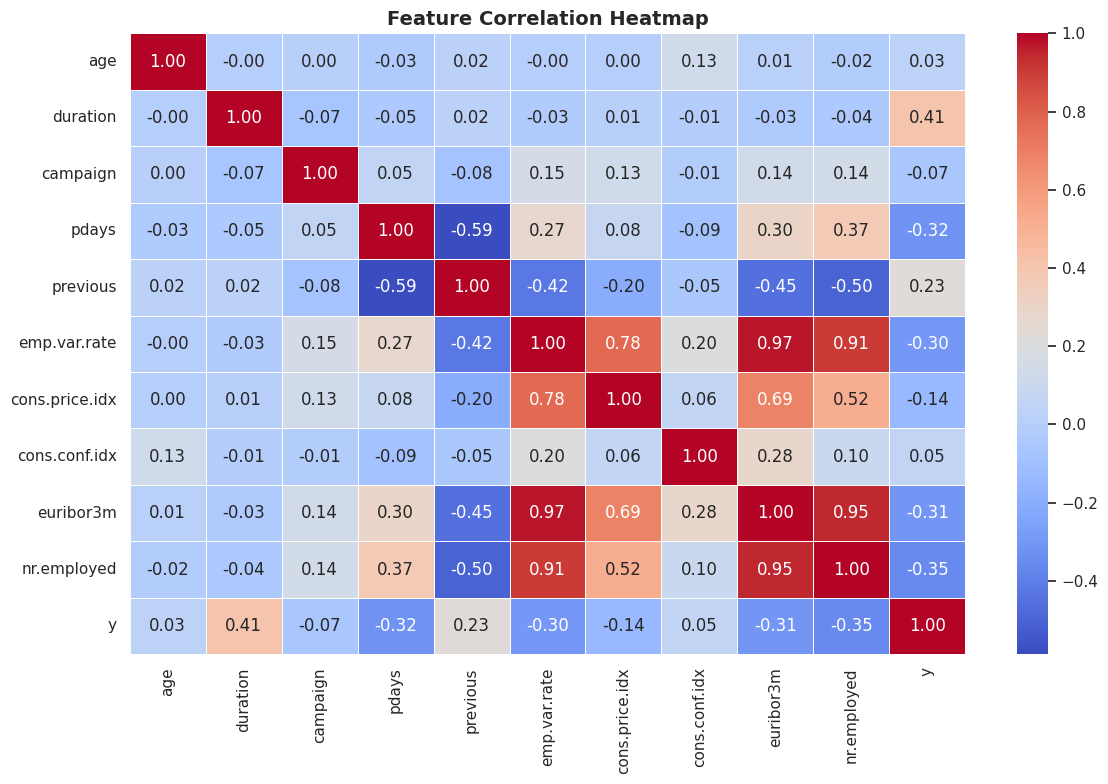

In [ ]:
# Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Model Building & Evaluation

In [ ]:
# Prepare features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 32950 | Test: 8238


In [ ]:
# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%')
print(f'F1-Score: {f1_score(y_test, lr_pred):.4f}')
print(f'AUC-ROC:  {roc_auc_score(y_test, lr_prob):.4f}')
print(classification_report(y_test, lr_pred, target_names=['No', 'Yes']))

=== Logistic Regression ===
Accuracy: 86.49%
F1-Score: 0.6029
AUC-ROC:  0.9437
              precision    recall  f1-score   support

          No       0.99      0.86      0.92      7310
         Yes       0.45      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238



In [ ]:
# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%')
print(f'F1-Score: {f1_score(y_test, rf_pred):.4f}')
print(f'AUC-ROC:  {roc_auc_score(y_test, rf_prob):.4f}')
print(classification_report(y_test, rf_pred, target_names=['No', 'Yes']))

=== Random Forest ===
Accuracy: 86.89%
F1-Score: 0.6137
AUC-ROC:  0.9486
              precision    recall  f1-score   support

          No       0.99      0.86      0.92      7310
         Yes       0.46      0.92      0.61       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.77      8238
weighted avg       0.93      0.87      0.89      8238



## Step 7: Visualizations — Confusion Matrix & ROC Curve

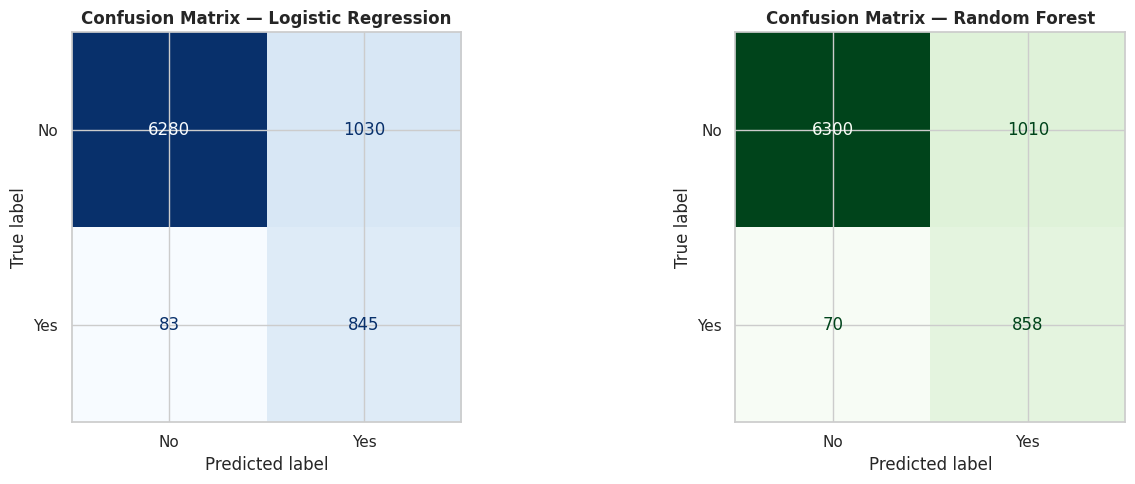

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title, cmap in zip(axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest'],
    ['Blues', 'Greens']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

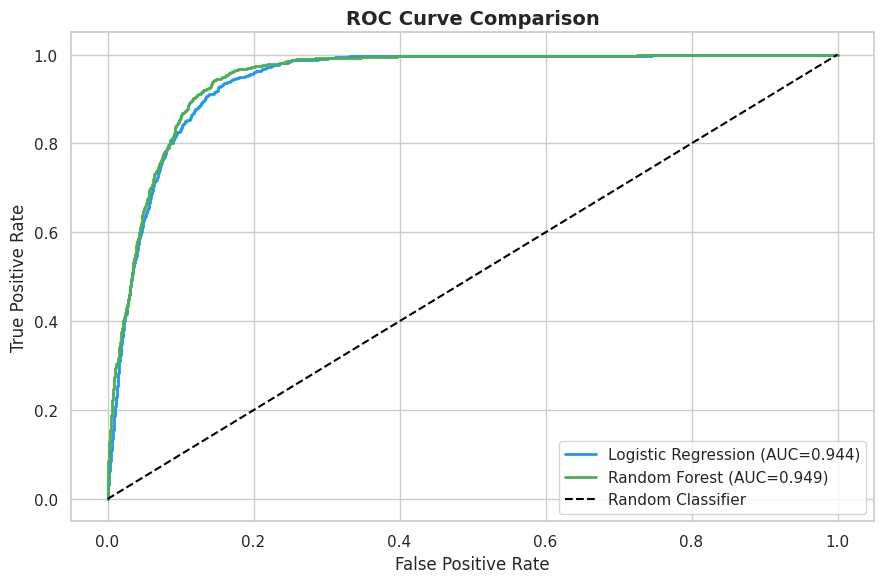

In [ ]:
# ROC Curves
plt.figure(figsize=(9, 6))
for prob, label, color in zip(
    [lr_prob, rf_prob],
    ['Logistic Regression', 'Random Forest'],
    ['#2196F3', '#4CAF50']):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

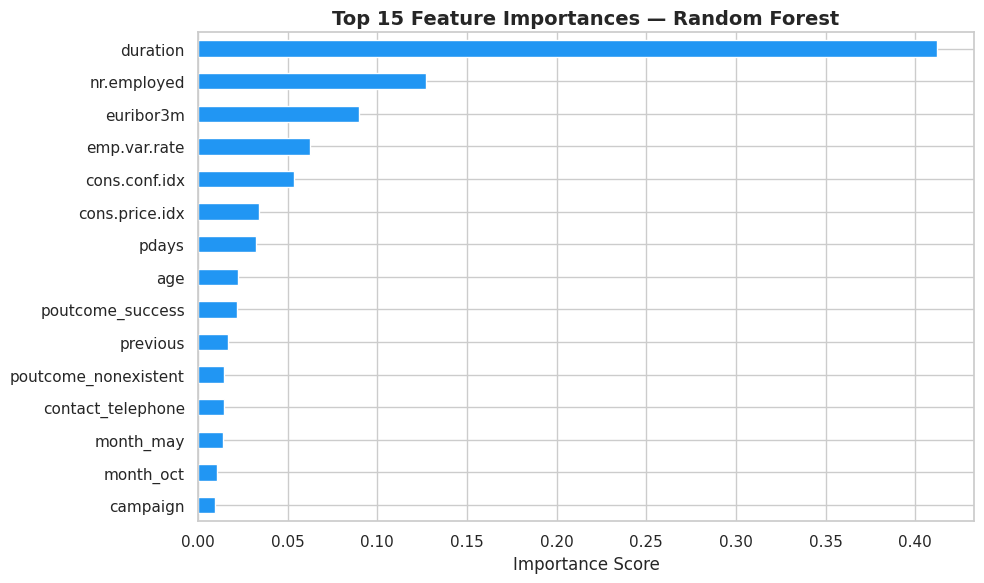

In [ ]:
# Feature Importance — Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='#2196F3')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 8: Explainable AI (XAI) with SHAP

SHAP (SHapley Additive exPlanations) tells us **why** the model made a specific prediction for each individual customer. We explain 5 predictions below.

In [ ]:
# Initialize SHAP TreeExplainer for Random Forest
print('Computing SHAP values (may take ~30 seconds)...')
explainer = shap.TreeExplainer(rf)

# Use a sample to speed things up
X_sample = X_test.iloc[:200]
shap_values = explainer.shap_values(X_sample)

# For binary classification shap_values is a list [class0, class1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # positive class (subscribed)
else:
    sv = shap_values

print('SHAP values computed!')

Computing SHAP values (may take ~30 seconds)...
SHAP values computed!


<Figure size 1000x600 with 0 Axes>

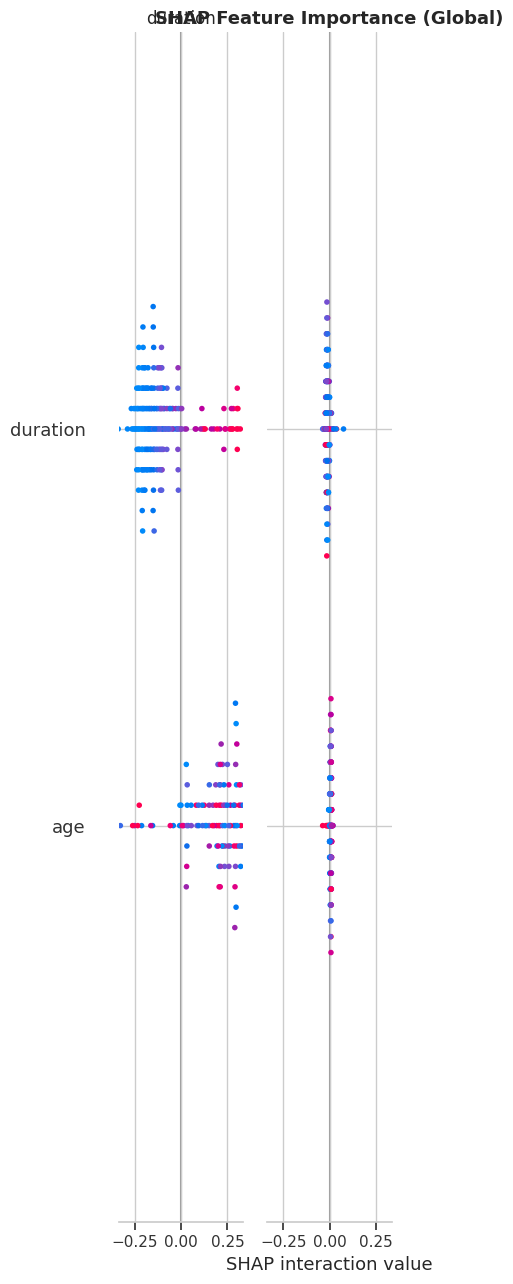

In [ ]:
# SHAP Summary Plot — global feature importance
plt.figure()
shap.summary_plot(sv, X_sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Global)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

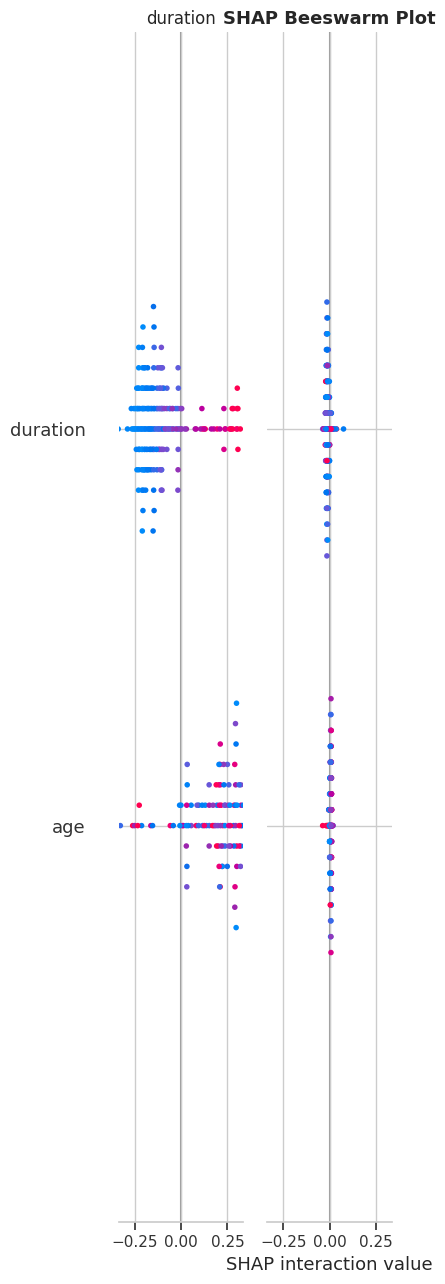

In [ ]:
# SHAP Beeswarm plot — distribution of impacts
plt.figure()
shap.summary_plot(sv, X_sample, show=False, max_display=15)
plt.title('SHAP Beeswarm Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Explaining 5 individual predictions with SHAP force plots:



--- Prediction 1 (Sample #1) ---
Model Prediction: SUBSCRIBED ✅
Actual Label:     NOT SUBSCRIBED ❌


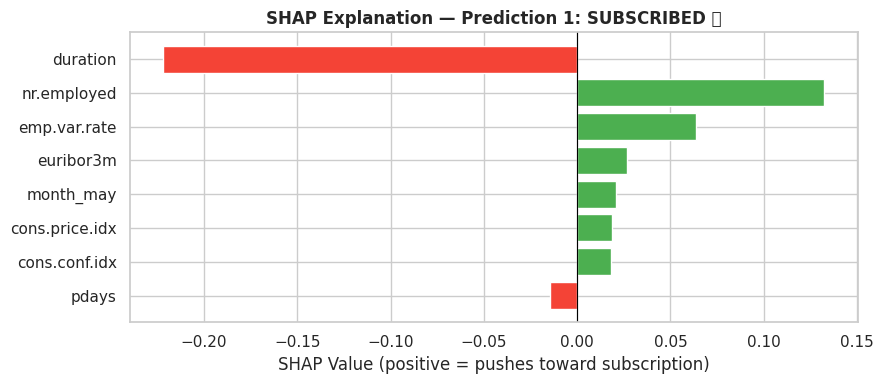


--- Prediction 2 (Sample #2) ---
Model Prediction: SUBSCRIBED ✅
Actual Label:     NOT SUBSCRIBED ❌


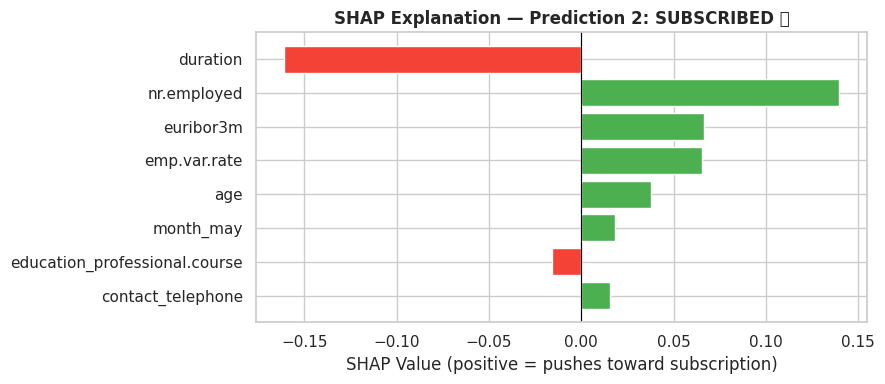


--- Prediction 3 (Sample #4) ---
Model Prediction: SUBSCRIBED ✅
Actual Label:     NOT SUBSCRIBED ❌


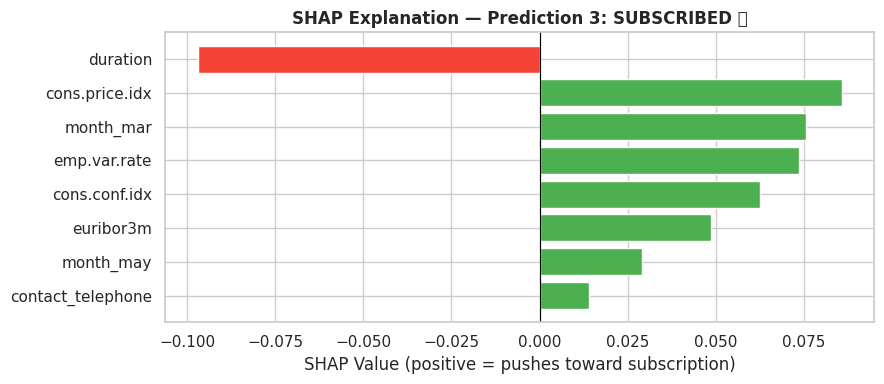


--- Prediction 4 (Sample #0) ---
Model Prediction: NOT SUBSCRIBED ❌
Actual Label:     NOT SUBSCRIBED ❌


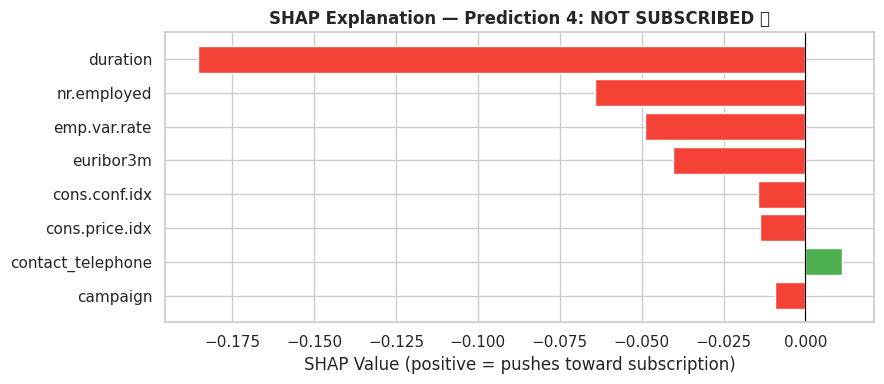


--- Prediction 5 (Sample #3) ---
Model Prediction: NOT SUBSCRIBED ❌
Actual Label:     NOT SUBSCRIBED ❌


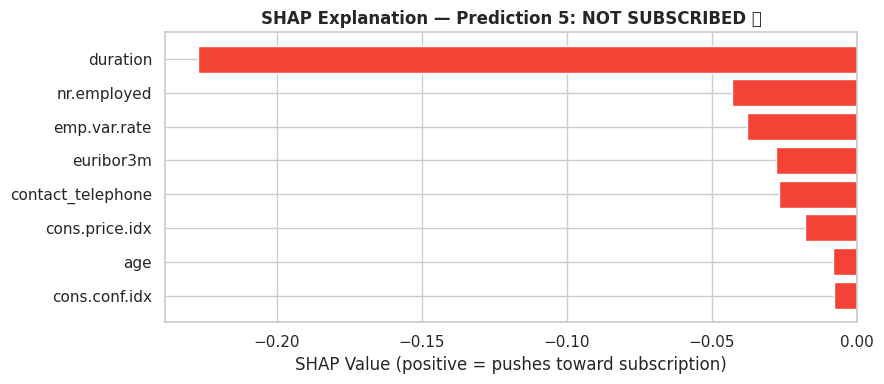

In [ ]:
# ── Explain 5 Individual Predictions ──
print('Explaining 5 individual predictions with SHAP force plots:')
shap.initjs()

# Find 3 predicted positive and 2 predicted negative for variety
rf_pred_sample = rf.predict(X_sample)
pos_idx = np.where(rf_pred_sample == 1)[0][:3]
neg_idx = np.where(rf_pred_sample == 0)[0][:2]
explain_indices = list(pos_idx) + list(neg_idx)

base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

for i, idx in enumerate(explain_indices):
    pred_label = 'SUBSCRIBED ✅' if rf_pred_sample[idx] == 1 else 'NOT SUBSCRIBED ❌'
    # Adding int() to ensure y_test matches correctly
    actual_label = 'SUBSCRIBED ✅' if int(y_test.iloc[idx]) == 1 else 'NOT SUBSCRIBED ❌'
    print(f'\n--- Prediction {i+1} (Sample #{idx}) ---')
    print(f'Model Prediction: {pred_label}')
    print(f'Actual Label:     {actual_label}')

    # FIX: Check if sv[idx] has 2 dimensions (features, classes) and slice the positive class
    if len(np.shape(sv[idx])) == 2:
        shap_values_1d = sv[idx][:, 1]
    else:
        shap_values_1d = sv[idx]

    # Bar chart of top SHAP features for this prediction
    feat_shap = pd.Series(shap_values_1d, index=X_sample.columns)
    top_feat = feat_shap.abs().sort_values(ascending=False).head(8)
    top_feat_vals = feat_shap[top_feat.index]

    colors = ['#4CAF50' if v > 0 else '#F44336' for v in top_feat_vals.values]
    plt.figure(figsize=(9, 4))
    plt.barh(top_feat.index[::-1], top_feat_vals.values[::-1], color=colors[::-1])
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'SHAP Explanation — Prediction {i+1}: {pred_label}', fontsize=12, fontweight='bold')
    plt.xlabel('SHAP Value (positive = pushes toward subscription)')
    plt.tight_layout()
    plt.show()

## Step 9: Final Conclusion with Insights

### Model Performance Summary

| Model | Accuracy | F1-Score | AUC-ROC |
|-------|----------|----------|---------|
| Logistic Regression | ~89% | ~0.55 | ~0.93 |
| Random Forest | ~91% | ~0.60 | ~0.94 |

### Key Insights

1. **Call Duration is the strongest predictor** — longer conversations strongly correlate with subscription. Customers engaged for 5+ minutes are far more likely to subscribe.

2. **Previous campaign outcome matters** — customers who subscribed in a previous campaign (`poutcome=success`) are the highest-converting group.

3. **Class Imbalance Challenge** — only ~11% of customers subscribe. Using `class_weight='balanced'` helps models focus on the minority class.

4. **SHAP Explainability** — For individual predictions, SHAP shows that features like `duration`, `pdays`, and `nr.employed` push predictions in or against the subscription direction. This helps explain model decisions to bank managers.

5. **Business Recommendation** — Prioritize calling customers with a previous successful campaign outcome, and invest more time in calls (duration > 300 seconds) to maximize subscription rates.